In [26]:
# import openkarst
import pykasso as pk
import importlib
importlib.reload(pk)
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import openkarst.models
importlib.reload(openkarst.models)
import openkarst.io.cave_data_loader as cdl
importlib.reload(cdl)
import seaborn as sns
import plotly.graph_objects as go

import openpnm as op
import contextily as cx
import geopandas as gpd
import pickle
from openkarst.network_generation import compute_conduit_lengths
from openkarst.visualization.animation_pyvista import animate_network
from openkarst.models import FlowSimulation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages

In [18]:
import utils.config as config
import utils.geos as geos
importlib.reload(config)
importlib.reload(geos)
from utils.utils import *
from utils.config import * 
from utils.calibration import *
from utils.conduits import *
from utils.geos import *

In [3]:
def main(geometry, base_dir = '.', inlets = [], outlets = [], cn_params = None, flowrate = 0, water_depth = 0.01, inlets_boundary = {'flow' : 0.01}, outlets_boundary ={'head' : 0.1}, steady_state = True, t_max = 1000, dt = 1, inflow_type = 'constant', end_time = 3600):
    
    # base_dir = os.path.dirname(os.path.abspath(__file__))
    
    # Setup flow simulation parameters
    physical_properties = {
        'water_density': 1000,        # kg/m^3
        'gravity': 9.81,              # m/s^2
        'dynamic_viscosity': 0.001,   # Pa.s (kg/m.s)
        'geometry_channel': False,    # Channel geometry for analytical solutions (Default False)
        'channel_type': 'infinite',   # 'infinite' for infinitely wide channel, 'finite' for defined width
        'channel_width': 1.0,         # Width of the channel (only used if channel_type is 'finite')
    }
    
    solver_settings = {
        'relaxation_factor': 0.6,    # Dimensionless
        'max_iterations': 20,        # Maximum Picard iterations
        'picard_depth_tol': 1e-7,    # Picard depth tolerance (meters)
        'ss_rel_l2tol': 1e-3,         # L2 tolerance for steady-state
        'ss_rel_madtol': 1e-8         # Median tolerance for steady-state
    }
    
    simulation_settings = {
        'min_waterdepth': 1e-10,      # Minimum water depth (meters)
        'min_flowrate': 1e-10,        # Minimum flow rate (m^3/s)
        'courant': 0.8,               # Courant number
        'adaptive_timesteps': True,   # Use adaptive timestepping
        'dt_init': dt,             # Initial (or constant) timestep (seconds)
        'dt_max': 1.0,                # Maximum allowable time step
        'steady_state': steady_state,         # Steady-state (True) or transient (False)
        't_max': t_max,              # Maximum time for transient simulations (seconds)
        'print_info_interval': 1000,     # Print info every # time steps
    }
    
    output_settings = {
        'output_interval': 10.0,
        'time': True,
        'time_step_size': True,
        'flowrates': True,
        'water_depths': True,
        'l2_norms': True,
        'convergence_fails': True,
        'reynolds_numbers': True,
    }
    
    logging_settings = {
        'base_dir': base_dir,
        'log_file': 'simulation.log'
    }
    
    # Create network object using OpenPNM
    dl = 1 # Constant spacing between nodes (meters)
    cn_geometry = geometry
    
    # Compute conduit lengths using the utility function
    cn_geometry = compute_conduit_lengths(cn_geometry)
    
    # Assign conduit properties
    for param, val in cn_params.items():
        print(param)
        cn_geometry[param] = val
    
    if inflow_type == 'timeseries':
        simulation_settings['adaptive_timesteps'] = False
    # Create flow network object
    flow_network = FlowSimulation(cn_geometry,
                                  physical_properties = physical_properties,
                                  solver_settings = solver_settings,
                                  simulation_settings = simulation_settings,
                                  logging_settings = logging_settings)
    
    # Set initial conditions
    initial_Q = np.full(cn_geometry.Nt, flowrate, dtype=float)   # Initial flows at each conduit (Nt throats)
    initial_y = np.full(cn_geometry.Np, water_depth, dtype=float)  # Initial water depths at each node (Np pores)    
    flow_network.set_initial_conditions(initial_Q, initial_y)
    
    # Set boundary conditions
    inflow_boundary = {}
    waterdepth_boundary = {}
    if 'flow' in inlets_boundary:
        if inflow_type == 'ramp':
            inflow_boundary.update({node: ('volumetric', (inlets_boundary['flow'], 10 * inlets_boundary['flow'])) for node in inlets})
        else:
            inflow_boundary.update({node: ('volumetric', inlets_boundary['flow']) for node in inlets})
    else: 
        waterdepth_boundary.update({node: inlets_boundary['head'] for node in inlets})
    if 'flow' in outlets_boundary:
        inflow_boundary.update({node: ('volumetric', outlets_boundary['flow']) for node in outlets})
    else: 
        waterdepth_boundary.update({node: outlets_boundary['head'] for node in outlets})
    print(inflow_boundary)


    flow_network.set_boundary_conditions(
    inflow_boundary=inflow_boundary,
    waterdepth_boundary=waterdepth_boundary,
    inflow_type=inflow_type,
    end_time= end_time)

    # Run simulation and store results
    results = flow_network.run_simulation(desired_outputs = output_settings)
    
    # Get arrays from results container
    Q_history = results['flowrates']
    y_history = results['water_depths']
    t_history = results['time']
    
    
    animation_settings = {
        'update_interval': 1,
        'conduit_plotradius': 0.5,
        'bar_plotradius': 0.5,
        'node_plotsize': 5,
        'depthscaling': 20,
        'fig_width': 1600,
        'fig_height': 800,
        'zoom_factor': 1.0,
        'background_color': 'black',
        'isometric_view': False,
        'create_animation': False,
        'filename': "network_animation2.mp4"
    }
    
    animate_network(cn_geometry=cn_geometry, 
                    Q_history=Q_history, 
                    y_history=y_history, 
                    t_history=t_history, 
                    **animation_settings)
    return results


In [19]:
nodes = pd.read_csv('../../data/networks/output_dye_trace_sump/nodes.csv')
edges = pd.read_csv('../../data/networks/output_dye_trace_sump/edges.csv')

<Axes: xlabel='x', ylabel='y'>

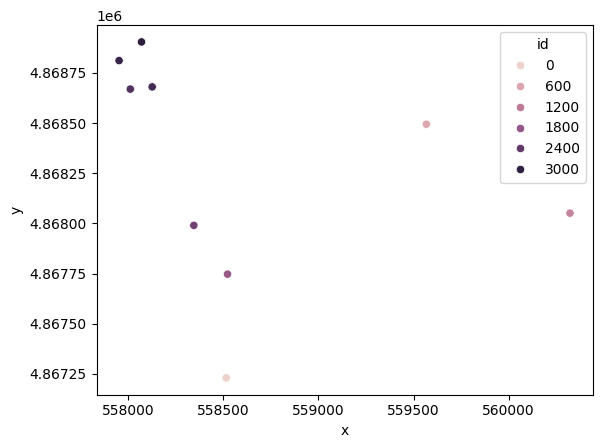

In [28]:
sns.scatterplot(nodes[nodes.type=='inlet'], x ='x', y = 'y', hue = 'id')

In [23]:
loader = cdl.CaveDataLoader(nodes = nodes, edges = edges )
geometry = loader.load_cave_data(d = 1)
inlets, outlets = loader.extract_boundary_nodes()

In [27]:
lines = edges[["x_0", "y_0", "z_0", "x_1", "y_1", "z_1"]].values.reshape(-1, 2, 3)
line_traces = []
for line in lines:
    line_traces.append(
        go.Scatter3d(
            x=line[:,0],
            y=line[:,1],
            z=line[:,2],
            mode='lines',
            line=dict(color='blue', width=1),
            showlegend=False
        )
    )
node_type_map = {cat: i for i, cat in enumerate(nodes.type.unique())}
node_colors = nodes.type.map(node_type_map)
# Scatter for nodes
scatter = go.Scatter3d(
    x=nodes.x,
    y=nodes.y,
    z=nodes.z,
    mode='markers',
    marker=dict(
        size=5,
        color=node_colors,  # categorical or numeric
        colorscale='Viridis',
        showscale=True
    )
)

# Combine and plot
fig = go.Figure(data=line_traces + [scatter])
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [ ]:
#getting discharge peak to recreate
Q = pd.read_csv('../../data/discharge/single_peak_05_01_2018.csv')
Q = convert_df_to_datetime(Q, 'datetime')

In [48]:
r = pd.read_csv('../../data/recharge/2018_recharge_zixuan.csv')
r = convert_df_to_datetime(r, 'DATE')
r = r[(r.DATE > '2018-04-15') & (r.DATE < '2018-06-15')]

In [45]:
Q.to_csv('../../data/discharge/single_peak_05_01_2018.csv', index = False)

(np.float64(17652.0), np.float64(17661.0))

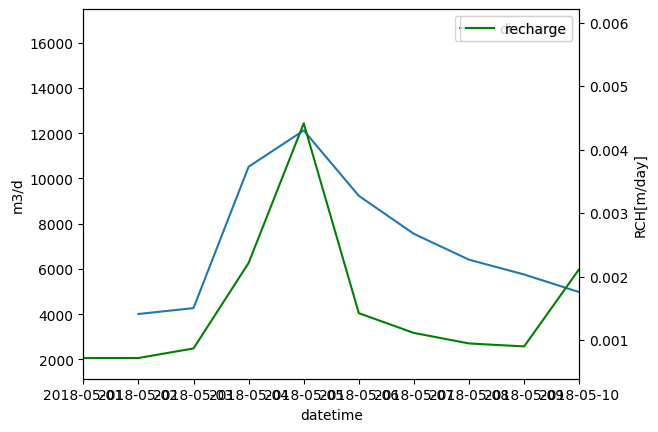

In [55]:
fig, ax = plt.subplots()
sns.lineplot(Q, x = 'datetime', y = 'm3/d', ax = ax, label = 'discharge')
sns.lineplot(r, x ='DATE', y = 'RCH[m/day]', ax = ax.twinx(), color = 'green', label = 'recharge')
plt.xlim(pd.to_datetime('2018-05-01'), pd.to_datetime('2018-05-10'))